<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Copy_of_Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset from the specified CSV file, specifying 'latin1' encoding
df = pd.read_csv('/content/FloridaBikeRentals.csv', encoding='latin1')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
# Check for null values in each column
null_counts = df.isnull().sum()
display(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("No missing values found in the DataFrame.")

,0


No missing values found in the DataFrame.


In [ ]:
# Check for null values in each column
null_counts = df.isnull().sum()
display(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("No missing values found in the DataFrame.")

,0


No missing values found in the DataFrame.


In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Extract day, month, and day of week
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6

# Create a column for weekdays/weekend
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

# Display the first few rows with the new columns
display(df.head())

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Day_of_Week,Is_Weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0


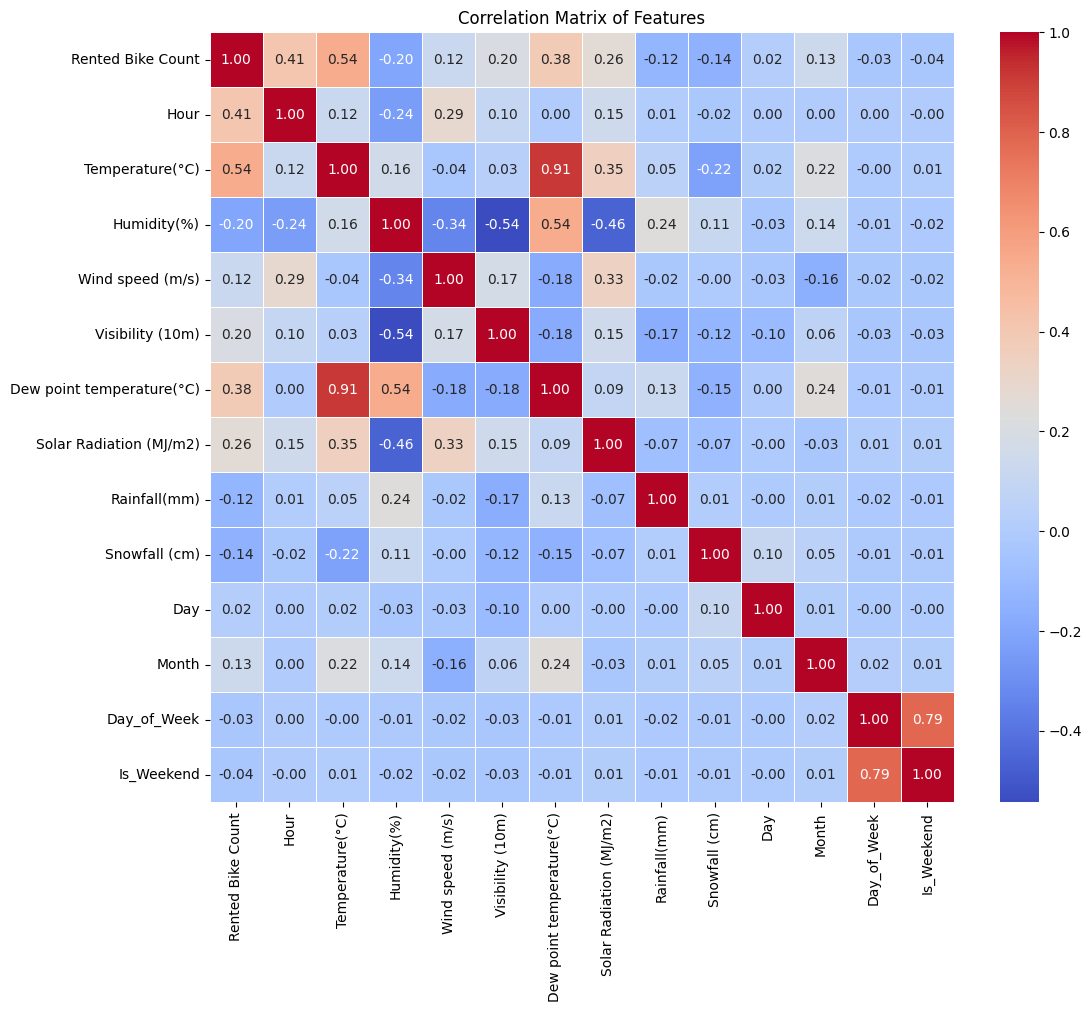

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

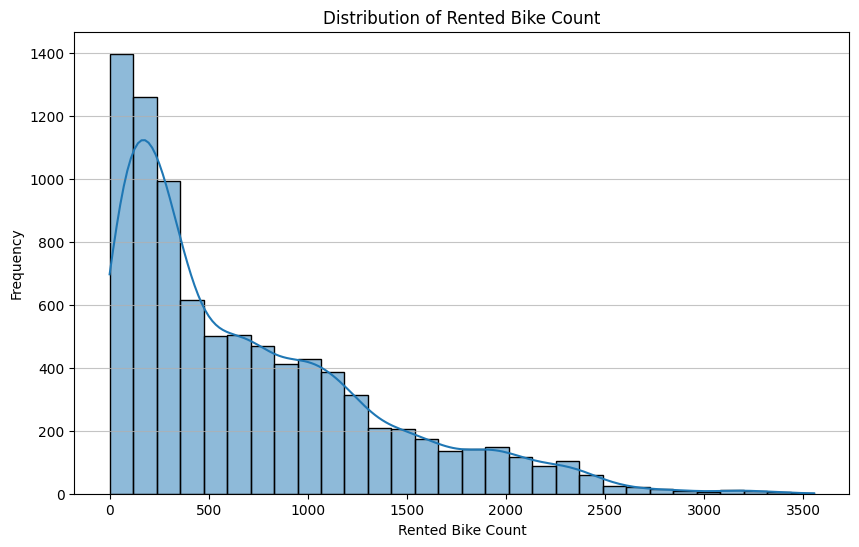

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Rented Bike Count'], kde=True, bins=30)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

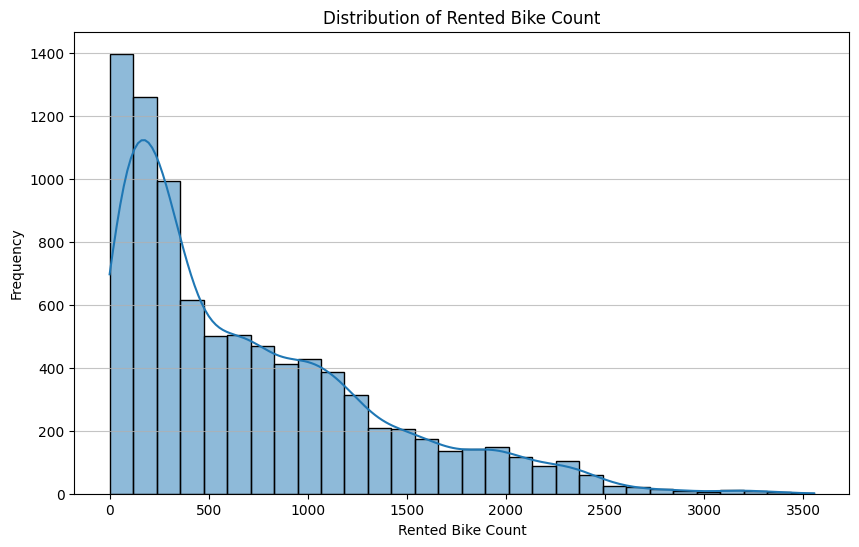

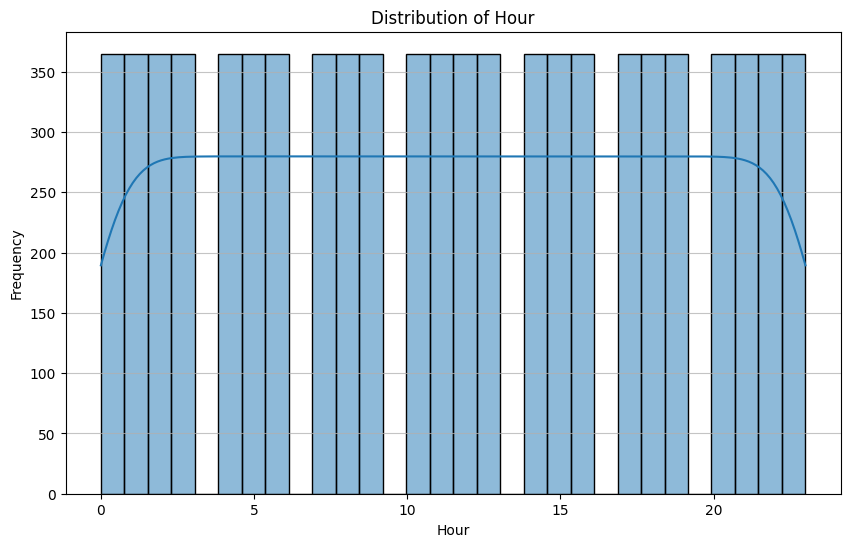

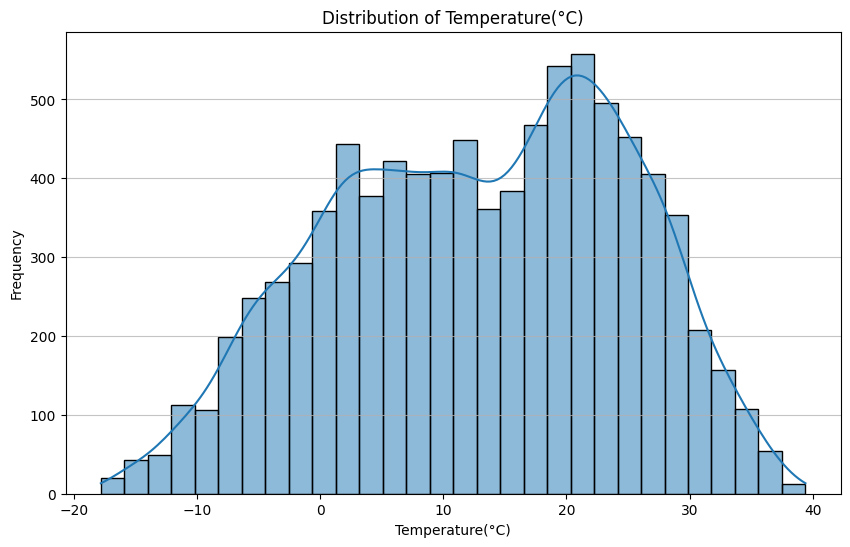

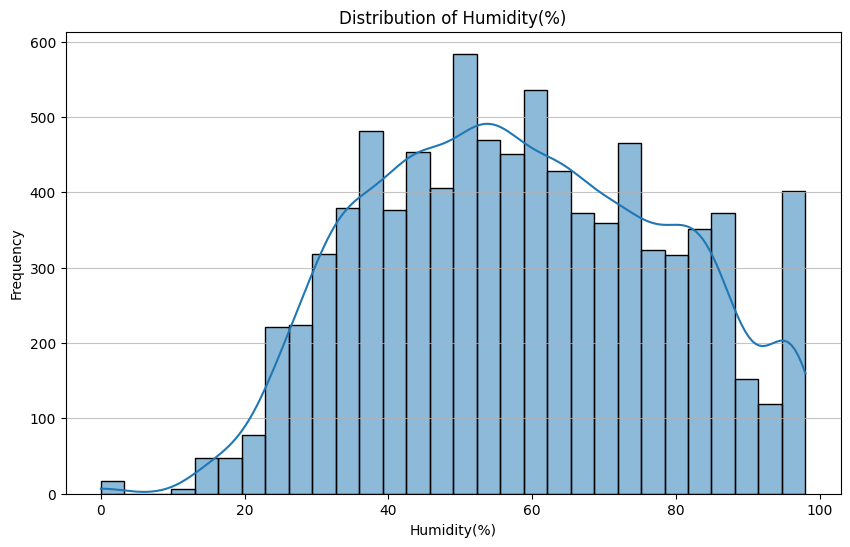

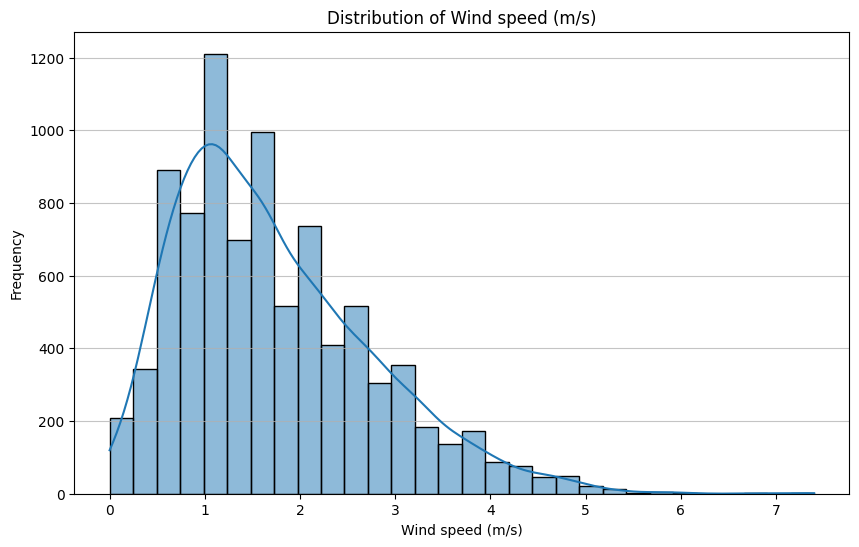

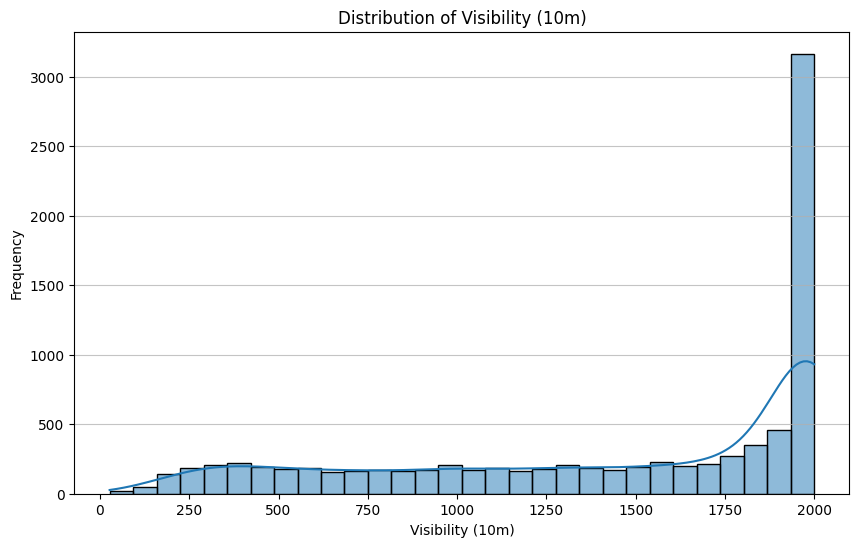

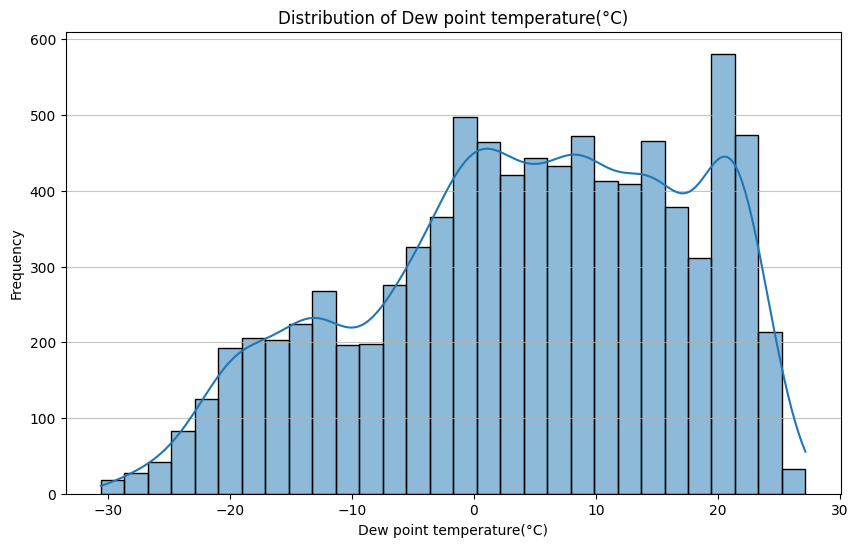

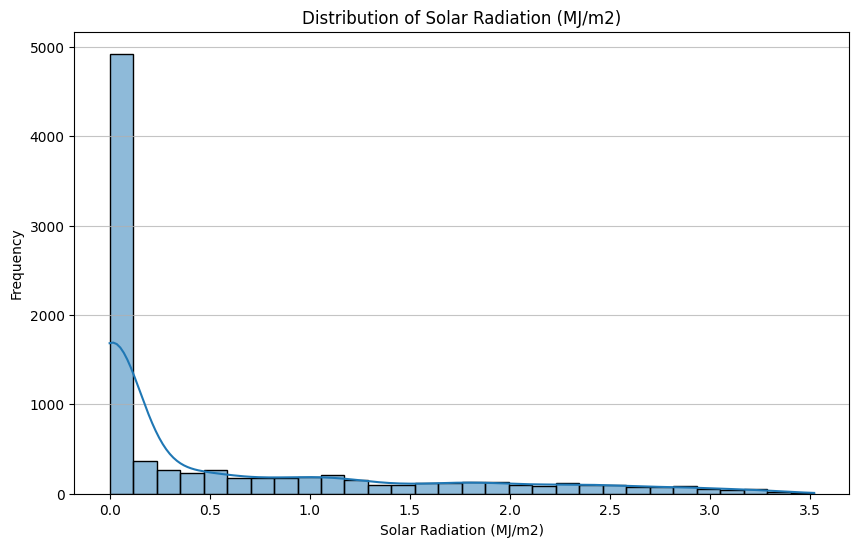

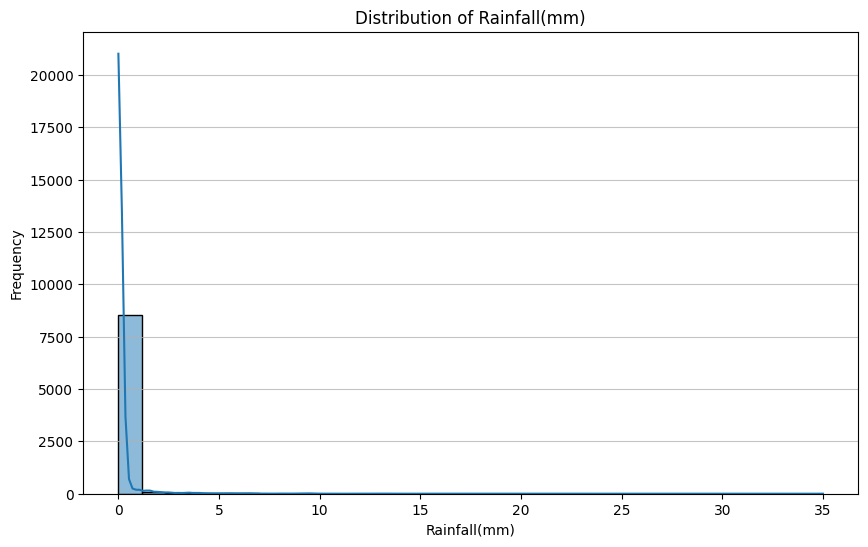

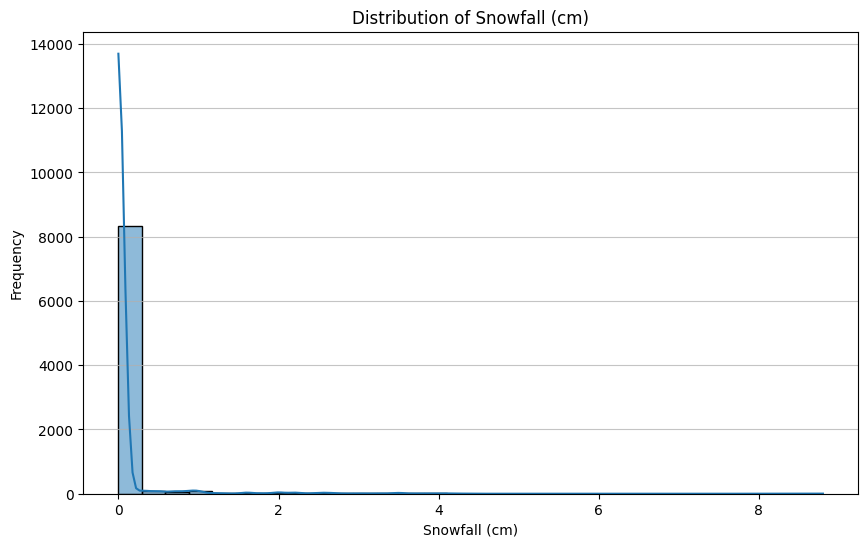

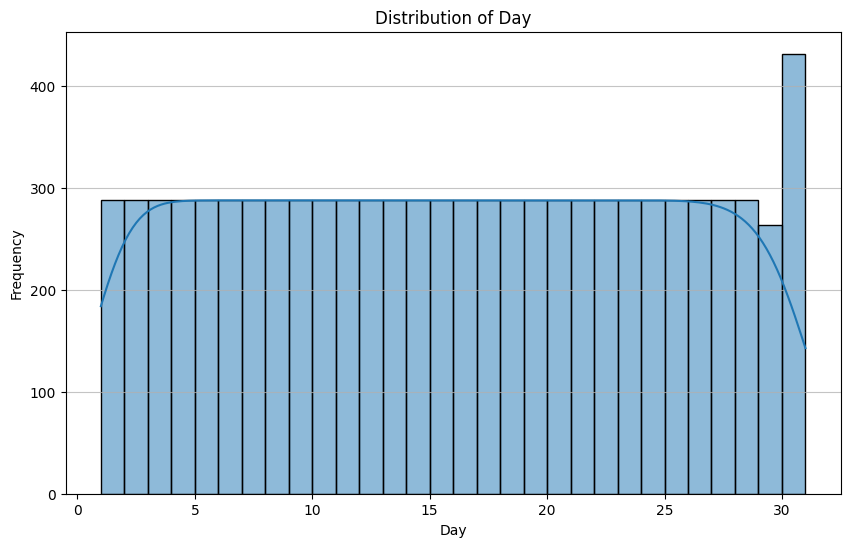

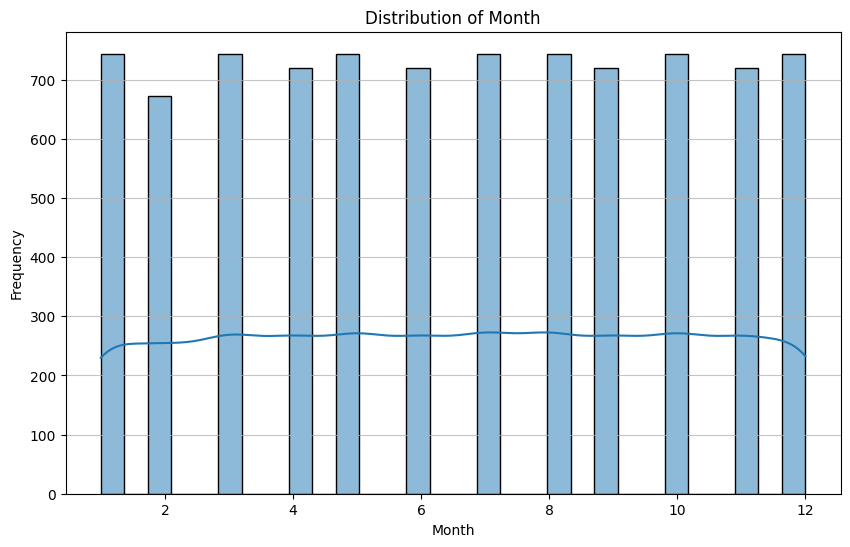

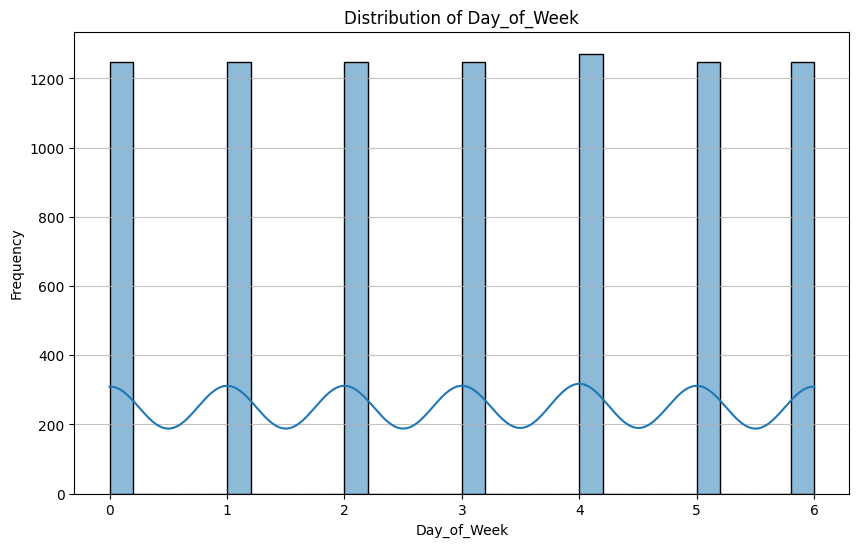

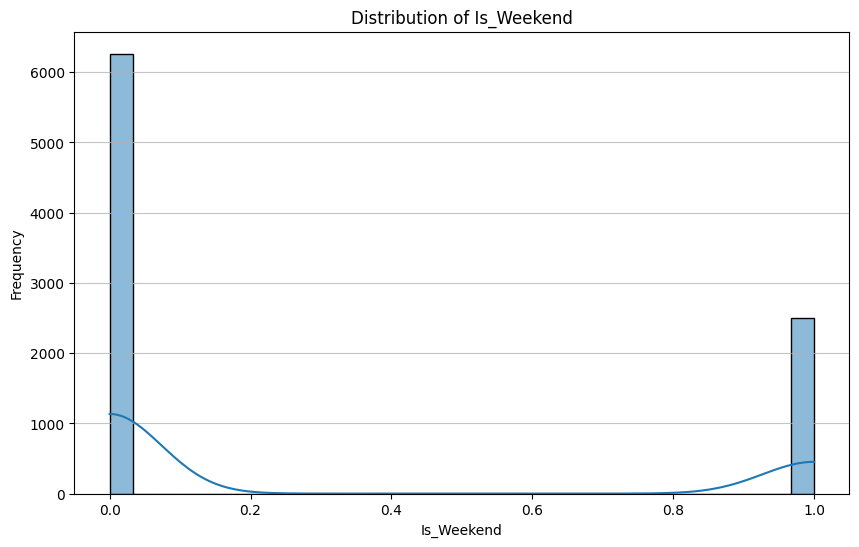

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Plot histograms for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

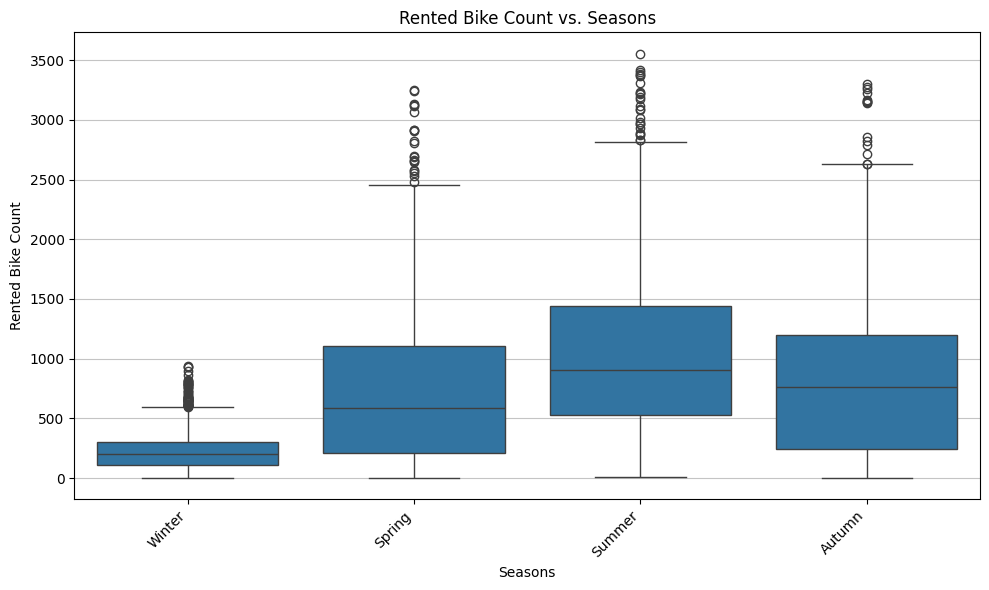

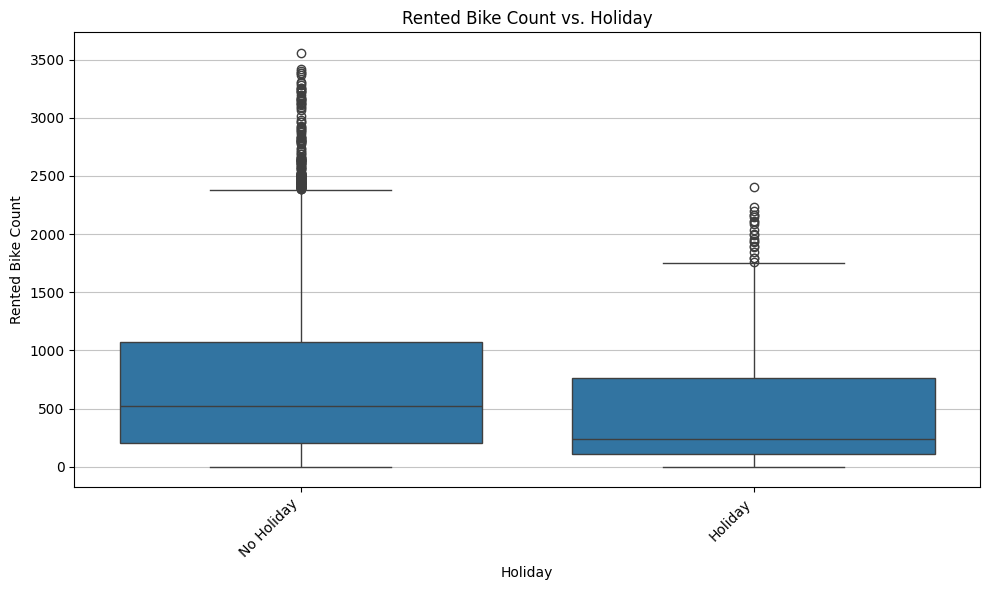

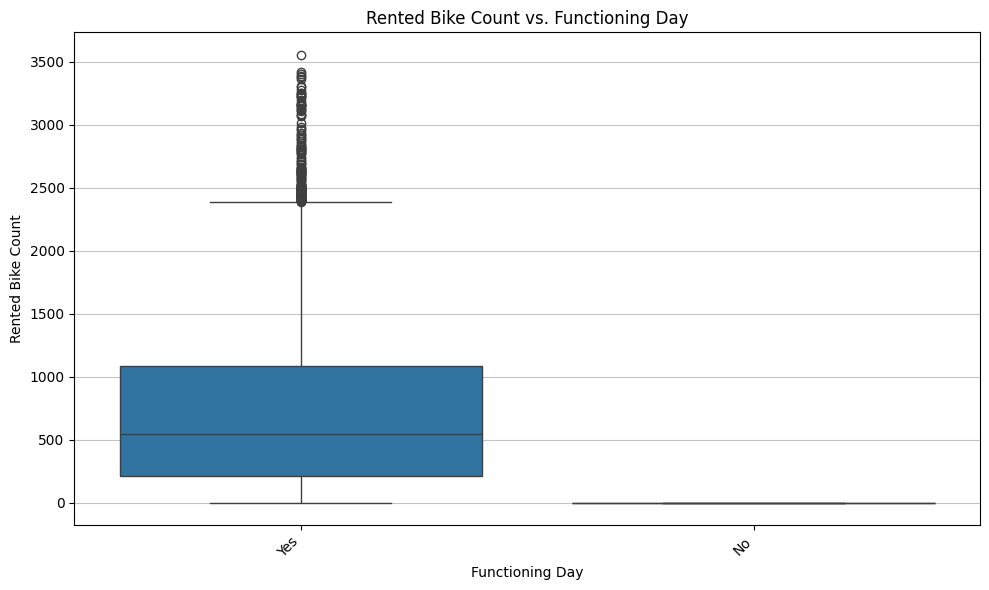

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Plot box plots for Rented Bike Count against each categorical column
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='Rented Bike Count', data=df)
    plt.title(f'Rented Bike Count vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Rented Bike Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they are long
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

<Figure size 1500x700 with 0 Axes>

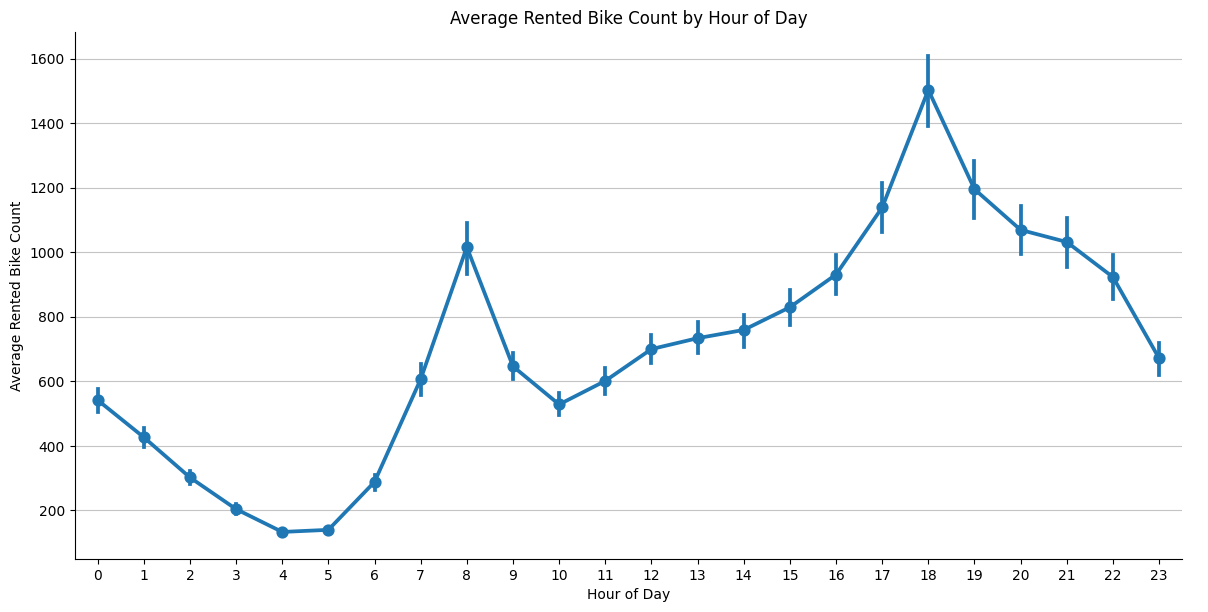

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rented Bike Count vs. Hour
plt.figure(figsize=(15, 7))
sns.catplot(x='Hour', y='Rented Bike Count', data=df, kind='point', height=6, aspect=2)
plt.title('Average Rented Bike Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rented Bike Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Inferences from Rented Bike Count vs. Hour:
This plot shows the average number of rented bikes at each hour of the day. We can observe peaks during morning and evening rush hours, indicating commuter usage, and lower counts during late night/early morning hours.

<Figure size 1000x600 with 0 Axes>

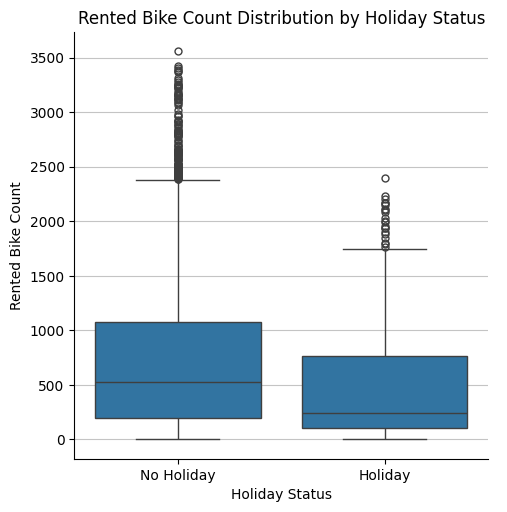

In [ ]:
# 2. Rented Bike Count vs. Holiday
plt.figure(figsize=(10, 6))
sns.catplot(x='Holiday', y='Rented Bike Count', data=df, kind='box', height=5, aspect=1)
plt.title('Rented Bike Count Distribution by Holiday Status')
plt.xlabel('Holiday Status')
plt.ylabel('Rented Bike Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Inferences from Rented Bike Count vs. Holiday:
The box plot illustrates the distribution of rented bike counts on holidays versus non-holidays. It helps to understand if holidays significantly impact bike rental demand compared to regular days.

<Figure size 1500x700 with 0 Axes>

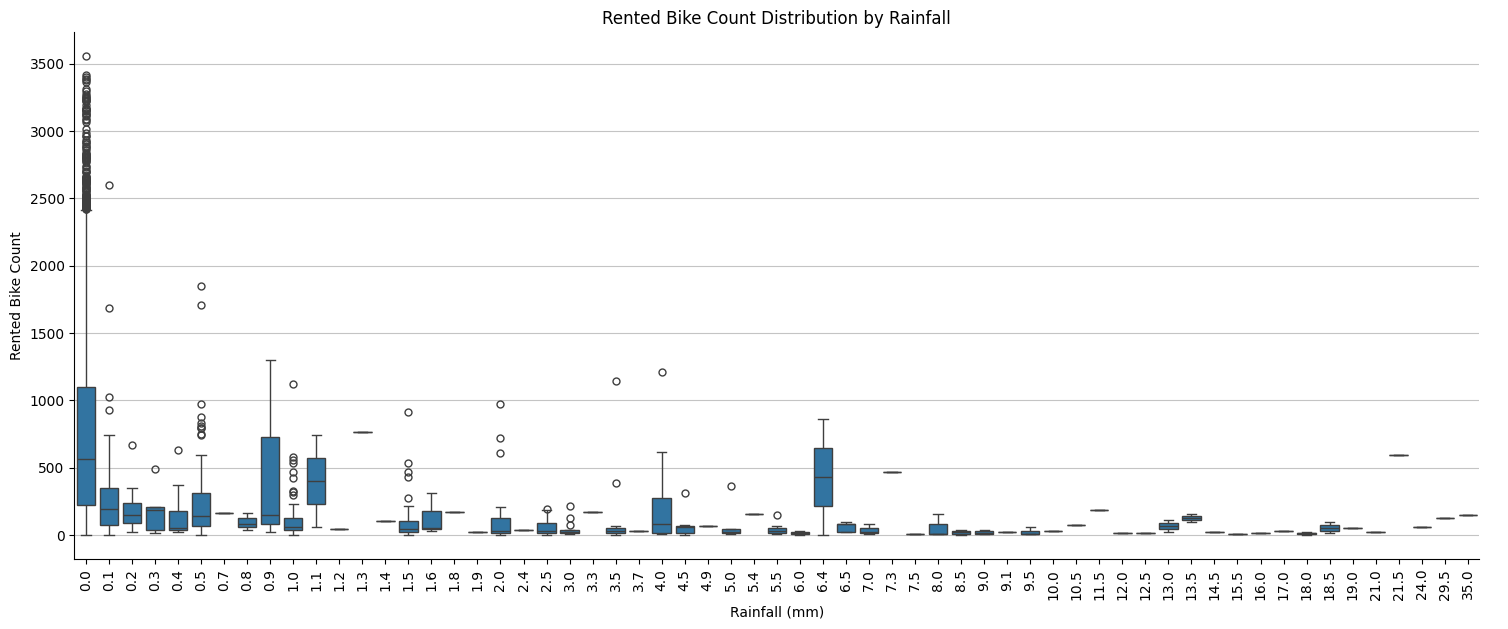

In [ ]:
# 3. Rented Bike Count vs. Rainfall(mm)
plt.figure(figsize=(15, 7))
sns.catplot(x='Rainfall(mm)', y='Rented Bike Count', data=df, kind='box', height=6, aspect=2.5)
plt.title('Rented Bike Count Distribution by Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Rented Bike Count')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Inferences from Rented Bike Count vs. Rainfall(mm):
This plot shows the distribution of rented bike counts across different rainfall amounts. Typically, higher rainfall would correlate with lower bike rental activity, which should be visible here.

<Figure size 1500x700 with 0 Axes>

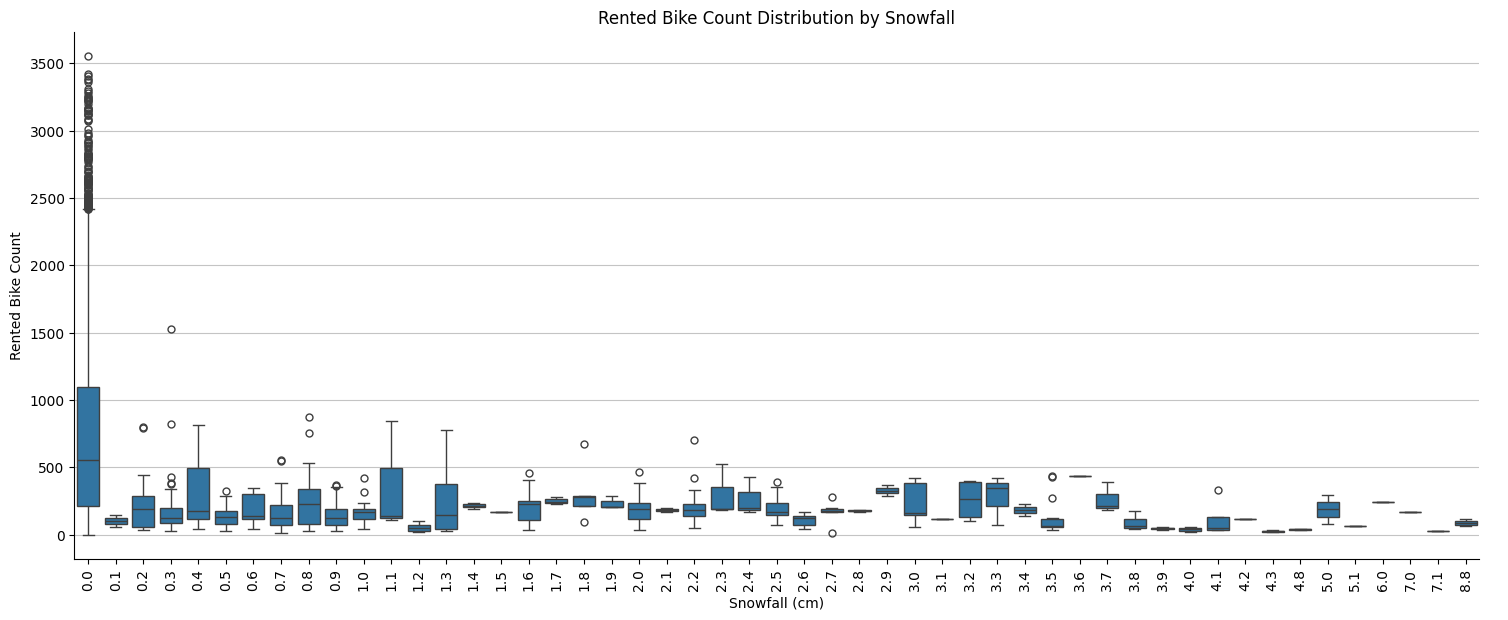

In [ ]:
# 4. Rented Bike Count vs. Snowfall (cm)
plt.figure(figsize=(15, 7))
sns.catplot(x='Snowfall (cm)', y='Rented Bike Count', data=df, kind='box', height=6, aspect=2.5)
plt.title('Rented Bike Count Distribution by Snowfall')
plt.xlabel('Snowfall (cm)')
plt.ylabel('Rented Bike Count')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Inferences from Rented Bike Count vs. Snowfall (cm):
Similar to rainfall, this plot visualizes the impact of snowfall on bike rentals. We would expect to see a decrease in bike usage as snowfall amounts increase, or even very low rental counts when there is any significant snowfall.

<Figure size 1000x600 with 0 Axes>

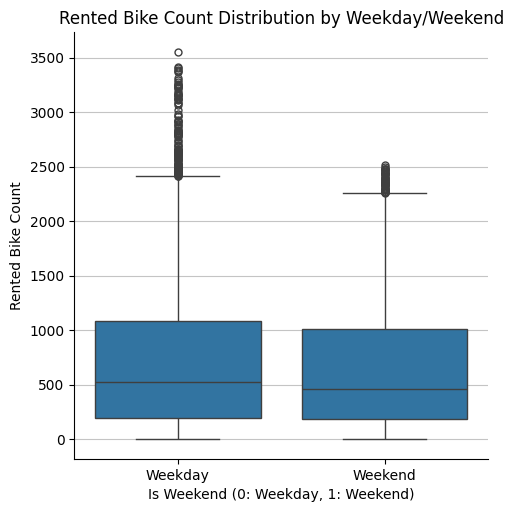

In [ ]:
# 5. Rented Bike Count vs. Weekdays/Weekend ('Is_Weekend' column)
plt.figure(figsize=(10, 6))
sns.catplot(x='Is_Weekend', y='Rented Bike Count', data=df, kind='box', height=5, aspect=1)
plt.title('Rented Bike Count Distribution by Weekday/Weekend')
plt.xlabel('Is Weekend (0: Weekday, 1: Weekend)')
plt.ylabel('Rented Bike Count')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.grid(axis='y', alpha=0.75)
plt.show()

### Inferences from Rented Bike Count vs. Weekday/Weekend:
This plot compares the distribution of rented bike counts between weekdays and weekends. It can reveal if there's a difference in rental patterns, e.g., higher rentals during weekdays for commuting or higher during weekends for leisure.

In [ ]:
# Select categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its shape
display(df_encoded.head())
print(f"Shape of original DataFrame: {df.shape}")
print(f"Shape of encoded DataFrame: {df_encoded.shape}")

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,Day_of_Week,Is_Weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,0,False,False,True,True,True
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,0,False,False,True,True,True
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,0,False,False,True,True,True
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,0,False,False,True,True,True
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,0,False,False,True,True,True


Shape of original DataFrame: (8760, 18)
Shape of encoded DataFrame: (8760, 20)


In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable
y = df_encoded['Rented Bike Count']

# Define the features by dropping the target variable and 'Date' column
X = df_encoded.drop(columns=['Rented Bike Count', 'Date'])

# Split the dataset into training and testing sets with a ratio of 80:20 and random state 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7008, 18)
Shape of X_test: (1752, 18)
Shape of y_train: (7008,)
Shape of y_test: (1752,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (7008, 18)
X_test_scaled shape: (1752, 18)


### 1. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate the model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression MAE: {mae_linear:.2f}")
print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Linear Regression R-squared: {r2_linear:.2f}")

Linear Regression MAE: 320.97
Linear Regression MSE: 185512.59
Linear Regression R-squared: 0.55


### 2. Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model (you can adjust alpha)
lasso_model = Lasso(alpha=0.1, random_state=1)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate the model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression MAE: {mae_lasso:.2f}")
print(f"Lasso Regression MSE: {mse_lasso:.2f}")
print(f"Lasso Regression R-squared: {r2_lasso:.2f}")

Lasso Regression MAE: 320.94
Lasso Regression MSE: 185492.06
Lasso Regression R-squared: 0.55


### 3. Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model (you can adjust alpha)
ridge_model = Ridge(alpha=1.0, random_state=1)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the model
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MAE: {mae_ridge:.2f}")
print(f"Ridge Regression MSE: {mse_ridge:.2f}")
print(f"Ridge Regression R-squared: {r2_ridge:.2f}")

Ridge Regression MAE: 320.96
Ridge Regression MSE: 185498.98
Ridge Regression R-squared: 0.55


### Comparison of Regression Models

Here's a summary of the performance metrics for each regression model:

| Model             | MAE   | MSE     | R-squared |
|-------------------|-------|---------|-----------|
| Linear Regression | {:.2f}  | {:.2f}   | {:.2f}     |
| Lasso Regression  | {:.2f}  | {:.2f}   | {:.2f}     |
| Ridge Regression  | {:.2f}  | {:.2f}   | {:.2f}     |

**Inferences:**

*   **R-squared** indicates how well the model explains the variability of the target variable. A higher R-squared suggests a better fit.
*   **MAE (Mean Absolute Error)** measures the average magnitude of the errors in a set of predictions, without considering their direction. It's a linear score, which means all individual differences are weighted equally in the average.
*   **MSE (Mean Squared Error)** measures the average of the squares of the errors. It penalizes larger errors more heavily than MAE, making it sensitive to outliers.

Based on these metrics, we can assess which model provides the best balance of accuracy and generalization for predicting bike rental counts. Typically, Lasso and Ridge regression are used to prevent overfitting by adding regularization terms, which can be particularly beneficial when dealing with many features or multicollinearity. The optimal model would likely be the one that achieves a good R-squared value while keeping MAE and MSE low on the test set, indicating both predictive power and accuracy without excessive error.

In [ ]:
# Check for null values in each column
null_counts = df.isnull().sum()
display(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("No missing values found in the DataFrame.")

,0


No missing values found in the DataFrame.
